# Projekt 1


# import bibliotek


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np

# Cześć 1b:

Trójkąt A ma narożniki o współrzędnych (2, 0.5, 10), (-1, -1.5, 12), (-1, 1.5, 8). Obie strony trójkąta mają różne kolory, tzn. czerwony RGB = (255,0,0) z jednej strony i zielony RGB = (0,255,0) z drugiej strony (wszystko jedno z której strony). Trójkąt B ma narożniki o współrzędnych (0.5, -2, 10), (-0.5, 2, 11), (1.5, 2, 9). Obie strony trójkąta mają różne kolory, tzn. niebieski RGB = (0,0,255) z jednej strony i żółty RGB = (255,255,0) z drugiej strony (wszystko jedno z której strony).

Wyświetl obraz cyfrowy pobrany przez kamerę obserwującą oba trójkąty w powyższej konfiguracji. Obraz ma mieć rozdzielczość XxY=640x480, a rozmiar pojedynczego pixela to 0.01x0.01. Zakładamy, że tło obrazu jest czarne, tzn. RGB = (0,0,0)

### Dodatek części B:

w trójkącie A dodatkowo pojawiła się trójkątna dziura zdefiniowana przez narożniki o współrzędnych: (0.8, 0.3, 10), (-0.25, -0.25, 10.5), (-0.25, 0.5, 9.5)


In [3]:
def mat2pix(m, n, dx, dy, x, y):
    transform_matrix = np.array(
        [[1.0 / dx, 0.0, 0.5 * m], [0.0, -1.0 / dy, 0.5 * n], [0.0, 0.0, 1.0]],
        dtype=float,
    )
    pixel_coords = transform_matrix @ np.array([x, y, 1.0], dtype=float)
    return round(pixel_coords[0] / pixel_coords[2], 0), round(
        pixel_coords[1] / pixel_coords[2], 0
    )


def pix2mat(m, n, dx, dy, u, v):
    transform_matrix = np.array(
        [[dx, 0.0, -0.5 * m * dx], [0.0, -dy, 0.5 * n * dy], [0.0, 0.0, 1.0]],
        dtype=float,
    )
    math_coords = transform_matrix @ np.array([u, v, 1.0], dtype=float)
    return math_coords[0] / math_coords[2], math_coords[1] / math_coords[2]


def Persp(f):
    h = np.zeros((4, 4), dtype=float)
    h[0, 0] = 1.0
    h[1, 1] = 1.0
    h[3, 2] = -1.0 / f
    h[3, 3] = 1.0
    return h


## Opis działania programu

Program renderuje dwa trójkąty 3D obserwowane przez kamerę. Najpierw wierzchołki są rzutowane perspektywicznie funkcją `Persp(f)`, a następnie ich współrzędne są zamieniane z układu matematycznego na układ pikseli. Na tej podstawie dla każdego trójkąta wyznaczane są trzy proste opisujące jego krawędzie w postaci `A*x + B*y + C`.

Sprawdzanie, czy dany piksel należy do trójkąta:
Dla każdego piksela liczone są wartości trzech funkcji krawędziowych i sprawdzany jest warunek `L0 >= 0 and L1 >= 0 and L2 >= 0`. Żeby ten test był prosty, współczynniki prostych są wcześniej orientowane tak, aby wybrany wierzchołek leżał po dodatniej stronie każdej krawędzi.

Kolor trójkąta wynika z geometrii 3D. Funkcja `triangle_color` liczy normalną z wektorów trójkąta `tri_3d` i na tej podstawie wybiera kolor frontowy albo tylny. Dzięki temu kolor zależy od tego, którą stroną trójkąt jest zwrócony do kamery.

### Z-buffer i dziury

Po sprawdzeniu, czy piksel leży wewnątrz trójkąta, liczymy jego odległość od rzutowanego na niego punktu z równania płaszczyzny `z = a*x + b*y + c`. Następnie porównujemy tę wartość z tablicą `zbuffer`. Jeśli nowy piksel jest bliżej kamery, nadpisujemy kolor w obrazie i zapisujemy nową głębokość.

W trójkącie A dodatkowo uwzględniamy dziurę. Dziura jest traktowana dokładnie tak samo jak zwykły trójkąt: rzutujemy ją na piksele, wyznaczamy jej krawędzie i jeśli punkt należy do dziury, pomijamy ten piksel podczas rysowania trójkąta A.

Funkcje kod do renderowania zostały zdefiniowany jako funkcje render_zbuffer i build_triangles tak aby uniknąć powtarzania kodu przy częsci 2.


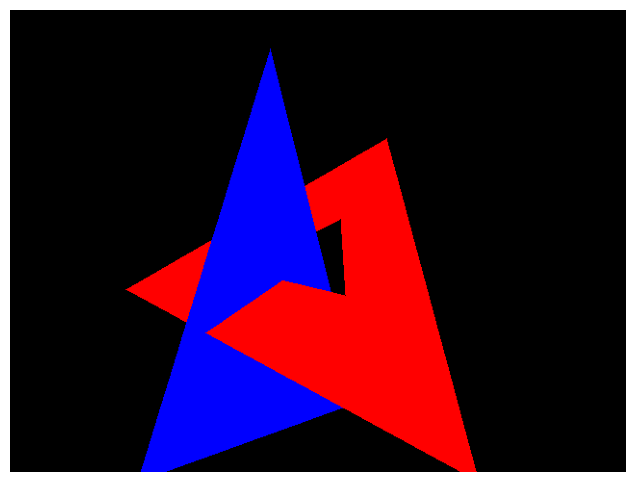

In [4]:
def project_triangle(triangle_3d, focal):
    # Projektuje 3D -> 2D (perspektywa) dla trzech wierzchołków trójkąta
    triangle_h = np.hstack((triangle_3d, np.ones((3, 1), dtype=float)))
    projected_h = (Persp(focal) @ triangle_h.T).T
    w = np.where(np.abs(projected_h[:, 3]) < 1e-12, 1e-12, projected_h[:, 3])
    return np.column_stack((projected_h[:, 0] / w, projected_h[:, 1] / w))


def triangle_normal(triangle_3d):
    # Oblicza wektor normalny trójkąta (z użyciem iloczynu wektorowego)
    v0, v1, v2 = triangle_3d
    return np.cross(v1 - v0, v2 - v0)


def triangle_color(triangle_3d, front_color, back_color):
    # Wybiera kolor w zależności od tego którą stroną trójkąt zwrócony jest do kamery
    normal = triangle_normal(triangle_3d)
    centroid = triangle_3d.mean(axis=0)
    camera = np.array([0.0, 0.0, f], dtype=float)
    view_vector = camera - centroid
    return front_color if np.dot(normal, view_vector) >= 0.0 else back_color


def fit_z_plane(proj_xy, tri_3d):
    # Dopasowuje parametry płaszczyzny z = a*x + b*y + c korzystając z trzech punktów
    M = np.column_stack((proj_xy[:, 0], proj_xy[:, 1], np.ones(3)))
    z = tri_3d[:, 2]
    a, b, c = np.linalg.solve(M, z)
    return a, b, c


# funkcja zwracająca współczynniki prostej przechodzącej przez a->b
# orientuje je tak aby reference_point dał wartość >= 0
def line_coeff(a, b, reference_point):
    A = a[1] - b[1]
    B = b[0] - a[0]
    C = a[0] * b[1] - b[0] * a[1]
    # jeśli reference point daje ujemną wartość, odwróć orientację
    val = A * reference_point[0] + B * reference_point[1] + C
    if val < 0:
        A, B, C = -A, -B, -C
    return A, B, C


def build_triangles(triangle_defs):
    triangles = []
    for tri_3d, hole_3d, front_col, back_col in triangle_defs:
        proj_xy = project_triangle(tri_3d, f)
        tri_px = np.array(
            [
                mat2pix(rozdzielczosc_x, rozdzielczosc_y, DX, DY, x, y)
                for x, y in proj_xy
            ],
            dtype=float,
        )

        A0, B0, C0 = line_coeff(tri_px[0], tri_px[1], tri_px[2])
        A1, B1, C1 = line_coeff(tri_px[1], tri_px[2], tri_px[0])
        A2, B2, C2 = line_coeff(tri_px[2], tri_px[0], tri_px[1])

        hole_lines = None
        if hole_3d is not None:
            hole_proj = project_triangle(hole_3d, f)
            hole_px = np.array(
                [
                    mat2pix(rozdzielczosc_x, rozdzielczosc_y, DX, DY, x, y)
                    for x, y in hole_proj
                ],
                dtype=float,
            )
            hA0, hB0, hC0 = line_coeff(hole_px[0], hole_px[1], hole_px[2])
            hA1, hB1, hC1 = line_coeff(hole_px[1], hole_px[2], hole_px[0])
            hA2, hB2, hC2 = line_coeff(hole_px[2], hole_px[0], hole_px[1])
            hole_lines = (hA0, hB0, hC0, hA1, hB1, hC1, hA2, hB2, hC2)

        a, b, c = fit_z_plane(proj_xy, tri_3d)
        color = triangle_color(tri_3d, front_col, back_col)

        triangles.append(
            {
                "lines": (A0, B0, C0, A1, B1, C1, A2, B2, C2),
                "hole_lines": hole_lines,
                "a": a,
                "b": b,
                "c": c,
                "color": color,
            }
        )
    return triangles


def render_zbuffer(triangles):
    """
    Funkcja renderująca obraz z algorytmem z-buffer. Przyjmuje listę trójkątów
    """
    image = np.zeros((rozdzielczosc_y, rozdzielczosc_x, 3), dtype=np.uint8)
    zbuffer = np.full((rozdzielczosc_y, rozdzielczosc_x), np.inf, dtype=float)

    for j in range(rozdzielczosc_y):
        for i in range(rozdzielczosc_x):
            x_img, y_img = pix2mat(rozdzielczosc_x, rozdzielczosc_y, DX, DY, i, j)
            for tri in triangles:
                A0, B0, C0, A1, B1, C1, A2, B2, C2 = tri["lines"]
                L0 = A0 * i + B0 * j + C0
                L1 = A1 * i + B1 * j + C1
                L2 = A2 * i + B2 * j + C2
                if (L0 >= 0) and (L1 >= 0) and (L2 >= 0):
                    if tri["hole_lines"] is not None:
                        hA0, hB0, hC0, hA1, hB1, hC1, hA2, hB2, hC2 = tri["hole_lines"]
                        hL0 = hA0 * i + hB0 * j + hC0
                        hL1 = hA1 * i + hB1 * j + hC1
                        hL2 = hA2 * i + hB2 * j + hC2
                        if (hL0 >= 0) and (hL1 >= 0) and (hL2 >= 0):
                            continue
                    z = tri["a"] * x_img + tri["b"] * y_img + tri["c"]
                    if z < zbuffer[j, i]:
                        zbuffer[j, i] = z
                        image[j, i] = tri["color"]

    return image, zbuffer


# PARAMETRY
rozdzielczosc_x = 640
rozdzielczosc_y = 480
DX = 0.01
DY = 0.01
f = 5.0

A = np.array([[2.0, 0.5, 10.0], [-1.0, -1.5, 12.0], [-1.0, 1.5, 8.0]], dtype=float)
A_hole = np.array(
    [[0.8, 0.3, 10.0], [-0.25, -0.25, 10.5], [-0.25, 0.5, 9.5]], dtype=float
)
B = np.array([[0.5, -2.0, 10.0], [-0.5, 2.0, 11.0], [1.5, 2.0, 9.0]], dtype=float)

triangles = build_triangles(
    [
        (
            A,
            A_hole,
            np.array([255, 0, 0], dtype=np.uint8),
            np.array([0, 255, 0], dtype=np.uint8),
        ),
        (
            B,
            None,
            np.array([0, 0, 255], dtype=np.uint8),
            np.array([255, 255, 0], dtype=np.uint8),
        ),
    ]
)

image, zbuffer = render_zbuffer(triangles)

# wyswietl wynik
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

# Część 2 (b) - animacja ruchu trójkątów

Początkowe położenia narożników trójkąta A to (2, 0, 0), (-1, -2, 2), i (-1 ,1, -2), a narożników
trójkąta B to (0, -2, 0), (-1 ,2, 1) i (1, 2, -1).
Wygeneruj animację złożoną ze 180 klatek wizualizującą opisany poniżej ruch obu trójkątów.
W każdej klatce położenie trójkąta opisane jest obrotem (w stosunku do pozycji początkowej)
oraz przesunięciem (też w stosunku do pozycji początkowej).
Obrót jest złożeniem obrotu
wokół osi OZ układu współrzędnych (tzn. kąt ROLL) oraz obrotu wokół osi OY układu
współrzędnych (tzn. kąt PITCH). Natomiast przesunięcia trójkątów w stosunku do położeń
początkowych opisane są zawsze takimi samymi wektorami, tzn. [px, py, pz]=[0, 0.5, 10] dla
trójkąta A oraz [px, py, pz]=[0.5, 0, 10] dla trójkąta B.

Obroty trójkątów w stosunku do położenia początkowego są następujące:

Trójkąt A
W n-tej klatce kąt ROLL ma wartość n×2.a stopnia (gdzie a jest piątą cyfrą Twojego
numeru albumu). Kąt PITCH ma wartość n×1.b stopnia (gdzie b jest szóstą cyfrą
Twojego numeru albumu).

Trójkąt B
W n-tej klatce kąt ROLL ma wartość -n×2.b stopnia (gdzie b jest szóstą cyfrą Twojego
numeru albumu). Kąt PITCH ma wartość -n×1.a stopnia (gdzie a jest piątą cyfrą
Twojego numeru albumu).

# Problemy do rozwiązania:

Ponieważ liczba klatek animacji wynosi 180, każdy z trójkątów wykona co najmniej jeden
pełny obrót kąta ROLL i co najmniej połowę pełnego obrotu kąta PITCH.
Zakładamy takie samo położenie kamery oraz takie same parametry obrazów cyfrowych
(klatek animacji) jak w Części 1, tzn. rozdzielczość klatek filmu wynosi XxY=640x480, a
rozmiar pojedynczego pixela to 0.01x0.01. Zakładamy, że tło animacji jest czarne.

Zrealizuj CZĘŚĆ 2(a), jeśli w trójkącie A dodatkowo pojawiła się trójkątna dziura
zdefiniowana przez narożniki o współrzędnych (w położeniu początkowym):
(0.8, -0.2, 0), (-0.25, -0.75, 0.5), (-0.25, 0, -0.5)

Każda klatka jest generowana za pomocą obrotu trójkątów względem ich pozycji początkowej.

Dla każdej klatki trzeba wyliczyć nowe pozycje wierzchołków trójkąta na podstawie wzoru.
Wykorzystując funkcje zdefiniowane w części 1 można wyświetlić animację. Trzeba jednak zwrócić uwagę na to że wektor normalny trójkąta zmieni się w czasie obrotu. Trzeba pamiętać która strona trójkąta jest "przodem" tak aby trójkąt wyliczony w innej klatce po obrocie 180 stopni był zwrócony inną stroną do kamery i miał inny kolor.

## Opis programu:

W tym programie wykorzystujemy funkcje RPYT do transformacji 3D wierzchołków trójkątów. Jest to funkcja z laboratorium nr 5. Zwraca ona macierz transformacji której można użyć do obrotu i przesunięcia punktu w przestrzeni 3D.

Funckja pomocnicza `apply_transform` pozwala na zastosowanie tej macierzy do zestawu punktów, co jest wygodne do aktualizacji pozycji trójkątów w każdej klatce animacji.

Podobnie jak w pierwszym zadaniu zaczynamy od zdefiniowania podanych trójkątów.

Wykorzystujemy tą samą logikę co w zadaniu 1 do renderowania trójkątów i obsługi z-buffera z tą różnicą że całość dzieje się w pętli i wyniki są zapisywanie do pliku video.

Do zapisania video w formacie avi wykorzystuję bibliotekę OpenCV - tak jak w laboratorium nr 4.


In [5]:
import cv2


def RPYT(roll, pitch, yaw, px, py, pz):
    r = np.deg2rad(roll)
    p = np.deg2rad(pitch)
    y = np.deg2rad(yaw)

    MR = np.array(
        [
            [np.cos(r), -np.sin(r), 0.0],
            [np.sin(r), np.cos(r), 0.0],
            [0.0, 0.0, 1.0],
        ],
        dtype=float,
    )

    MP = np.array(
        [
            [np.cos(p), 0.0, np.sin(p)],
            [0.0, 1.0, 0.0],
            [-np.sin(p), 0.0, np.cos(p)],
        ],
        dtype=float,
    )

    MY = np.array(
        [
            [1.0, 0.0, 0.0],
            [0.0, np.cos(y), -np.sin(y)],
            [0.0, np.sin(y), np.cos(y)],
        ],
        dtype=float,
    )

    Rot = MY @ MP @ MR

    Hmat = np.zeros((4, 4), dtype=float)
    Hmat[:3, :3] = Rot
    Hmat[0, 3] = px
    Hmat[1, 3] = py
    Hmat[2, 3] = pz
    Hmat[3, 3] = 1.0

    return Hmat


def apply_transform(vertices_3d, Hmat):
    vertices_h = np.hstack((vertices_3d, np.ones((3, 1), dtype=float)))
    transformed = (Hmat @ vertices_h.T).T
    w = transformed[:, 3:4]
    return transformed[:, :3] / w


A0_2b = np.array([[2.0, 0.0, 0.0], [-1.0, -2.0, 2.0], [-1.0, 1.0, -2.0]], dtype=float)
A0_hole_2b = np.array(
    [[0.8, -0.2, 0.0], [-0.25, -0.75, 0.5], [-0.25, 0.0, -0.5]], dtype=float
)
B0_2b = np.array([[0.0, -2.0, 0.0], [-1.0, 2.0, 1.0], [1.0, 2.0, -1.0]], dtype=float)

frame_count = 180
short_start = 36
short_end = 45


fourcc = cv2.VideoWriter_fourcc(*"XVID")
full_writer = cv2.VideoWriter(
    "full.avi", fourcc, 30, (rozdzielczosc_x, rozdzielczosc_y)
)
short_writer = cv2.VideoWriter(
    "short.avi", fourcc, 30, (rozdzielczosc_x, rozdzielczosc_y)
)

for n in range(frame_count):
    print(f"Generowanie klatki {n + 1}/{frame_count}...")
    roll_a = n * 2.4
    pitch_a = n * 1.1
    roll_b = -n * 2.1
    pitch_b = -n * 1.4

    H_a = RPYT(roll_a, pitch_a, 0.0, 0.0, 0.5, 10.0)
    H_b = RPYT(roll_b, pitch_b, 0.0, 0.5, 0.0, 10.0)

    A_2b = apply_transform(A0_2b, H_a)
    A_hole_2b = apply_transform(A0_hole_2b, H_a)
    B_2b = apply_transform(B0_2b, H_b)

    triangles = build_triangles(
        [
            (
                A_2b,
                A_hole_2b,
                np.array([255, 0, 0], dtype=np.uint8),
                np.array([0, 255, 0], dtype=np.uint8),
            ),
            (
                B_2b,
                None,
                np.array([0, 0, 255], dtype=np.uint8),
                np.array([255, 255, 0], dtype=np.uint8),
            ),
        ]
    )

    image, _ = render_zbuffer(triangles)
    bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    full_writer.write(bgr)
    if short_start <= n <= short_end:
        short_writer.write(bgr)

full_writer.release()
short_writer.release()

Generowanie klatki 1/180...


KeyboardInterrupt: 